# Building a Classifier to Predict Wildfire Size

### Charlie Hoose

The goal of this project is to create a model to predict the final size of a wildfire. This was originally done in November of 2023 as part of a final project for the Data Science Union curriculum, however it has been updated in April of 2026 as I have learned substantially more about ML. 

The data comes from the 2023 Wildland Fire Incident Report that is used internally by situation unit leaders and GIS experts in the field. Due to permissions issues, I cannot include the dataset in this report.

In [ ]:
# read datasets, packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
import joblib
import json

df = pd.read_excel(r'/Users/charliehoose/Desktop/DSU/Projects/Curriculum Project/2023WildlandFireIncidents.xls')
df.head()

,FID,SourceOID,ABCDMisc,ADSPermiss,Containmen,ControlDat,CreatedByS,IncidentSi,DiscoveryA,DispatchCe,...,EstimatedF,Organizati,StrategicD,CreatedOnD,ModifiedOn,IsCpxChild,CpxName,CpxID,SourceGlob,GlobalID
0,0,23872143,,DEFAULT,NaT,NaT,lacocad,0.00,0.01,CALACC,...,0,,NaT,2023-01-01,2023-01-01,0,,,{46374510-C3AE-4B21-BF99-F6E8DCE39EA7},{bb4a69d2-8ce1-4e2f-b8b4-c589ee47536b}
1,1,23872145,,DEFAULT,2023-01-01,2023-01-01,cfcad,0.01,0.01,CAFKCC,...,0,,NaT,2023-01-01,2023-01-01,0,,,{B7688735-6981-41E5-B06C-235A96FEABE3},{d4ca8250-a331-4193-84e7-d022727792e1}
2,2,23872184,,DEFAULT,NaT,NaT,lacocad,0.00,0.01,CALACC,...,0,,NaT,2023-01-01,2023-01-01,0,,,{8DC41F9E-8F7F-435B-BFA1-BBBD7B4DE521},{92c597a7-b3e6-4f83-8309-fb25c6da6a5b}
3,3,23872185,,DEFAULT,NaT,NaT,cfcad,0.00,0.01,CARRCC,...,0,,NaT,2023-01-01,2023-01-01,0,,,{5977CB1E-0C9B-4523-A3F1-DF1A9B7A04E5},{011f9ed0-f42e-4d21-88dd-5bd442b20a58}
4,4,23872187,,DEFAULT,NaT,NaT,cfcad,0.00,0.01,CARRCC,...,0,,NaT,2023-01-01,2023-01-01,0,,,{D57703B0-60A2-4F8C-91F9-204E5282DB63},{fa343640-3900-49ce-b93f-f36d05650ea8}


## Data Preprocessing

In [4]:
# shrink dataset to just the columns we care about
df = df[['IncidentSi', 'DiscoveryA', 'POOState', 'GACC',
                   'FireDiscov', 'POOLandown', 'FireCause',
                   'FireBehavi', 'FireBeha_2', 'FireBeha_3',
                   'FireCauseG', 'PrimaryFue', 'SecondaryF']]
df.head()

,IncidentSi,DiscoveryA,POOState,GACC,FireDiscov,POOLandown,FireCause,FireBehavi,FireBeha_2,FireBeha_3,FireCauseG,PrimaryFue,SecondaryF
0,0.00,0.01,US-CA,OSCC,2023-01-01,Private,Undetermined,,,,,,
1,0.01,0.01,US-CA,OSCC,2023-01-01,Private,Undetermined,,,,,,
2,0.00,0.01,US-CA,OSCC,2023-01-01,Private,Undetermined,,,,,,
3,0.00,0.01,US-CA,OSCC,2023-01-01,Private,Undetermined,,,,,,
4,0.00,0.01,US-CA,OSCC,2023-01-01,Private,Undetermined,,,,,,


In [5]:
# make the incident size, discover acres to log to decrease skewedness
df['IncidentSi'] = np.log(df['IncidentSi'] + 1)
df['DiscoveryA'] = np.log(df['DiscoveryA'] + 1)

In [6]:
# replace blank values with "Undetermined" or "No Behavior" as appropriate

# FireBehavi
df['FireBehavi'] = df['FireBehavi'].replace(' ', 'No Behavior')

# FireBeha_2
df['FireBeha_2'] = df['FireBeha_2'].replace(' ', 'No Behavior')

# FireBeha_3
df['FireBeha_3'] = df['FireBeha_3'].replace(' ', 'No Behavior')

# FireCause
df['FireCause'] = df['FireCause'].replace(' ', 'Undetermined')

# FireCauseG
df['FireCauseG'] = df['FireCauseG'].replace(' ', 'Undetermined (remarks required)')
df['FireCauseG'] = df['FireCauseG'].replace('Undetermined (remarks required)', 'Other causes')

# PrimaryFue
df['PrimaryFue'] = df['PrimaryFue'].replace(' ', 'Undetermined')

# SecondaryF
df['SecondaryF'] = df['SecondaryF'].replace(' ', 'Undetermined')

df.head()


,IncidentSi,DiscoveryA,POOState,GACC,FireDiscov,POOLandown,FireCause,FireBehavi,FireBeha_2,FireBeha_3,FireCauseG,PrimaryFue,SecondaryF
0,0.00000,0.00995,US-CA,OSCC,2023-01-01,Private,Undetermined,No Behavior,No Behavior,No Behavior,Other causes,Undetermined,Undetermined
1,0.00995,0.00995,US-CA,OSCC,2023-01-01,Private,Undetermined,No Behavior,No Behavior,No Behavior,Other causes,Undetermined,Undetermined
2,0.00000,0.00995,US-CA,OSCC,2023-01-01,Private,Undetermined,No Behavior,No Behavior,No Behavior,Other causes,Undetermined,Undetermined
3,0.00000,0.00995,US-CA,OSCC,2023-01-01,Private,Undetermined,No Behavior,No Behavior,No Behavior,Other causes,Undetermined,Undetermined
4,0.00000,0.00995,US-CA,OSCC,2023-01-01,Private,Undetermined,No Behavior,No Behavior,No Behavior,Other causes,Undetermined,Undetermined


In [7]:
# For FireBehavi column, since it doesnt need dummies
replace_values = {'No Behavior' : 0, 'Minimal' : 1, 'Moderate' : 2, 'Active' : 3, 'Extreme' : 4}
df['FireBehavi'] = df['FireBehavi'].replace(replace_values)

# Making dummies for the other columns
data = pd.get_dummies(df, columns=['FireBeha_2', 'FireBeha_3', 'FireCause',
'FireCauseG', 'PrimaryFue', 'SecondaryF'])

data.head()

,IncidentSi,DiscoveryA,POOState,GACC,FireDiscov,POOLandown,FireBehavi,FireBeha_2_Backing,FireBeha_2_Creeping,FireBeha_2_Crowning,...,SecondaryF_Hardwood Litter,SecondaryF_Heavy Logging Slash,SecondaryF_Light Logging Slash,SecondaryF_Medium Logging Slash,SecondaryF_Short Grass (1 foot),SecondaryF_Southern Rough,SecondaryF_Tall Grass (2.5 feet),SecondaryF_Timber (Grass and Understory),SecondaryF_Timber (Litter and Understory),SecondaryF_Undetermined
0,0.00000,0.00995,US-CA,OSCC,2023-01-01,Private,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,0.00995,0.00995,US-CA,OSCC,2023-01-01,Private,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,0.00000,0.00995,US-CA,OSCC,2023-01-01,Private,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0.00000,0.00995,US-CA,OSCC,2023-01-01,Private,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,0.00000,0.00995,US-CA,OSCC,2023-01-01,Private,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [9]:
import warnings
warnings.filterwarnings('ignore')

data2 = data.copy()

# Combine FireBeha_2 and FireBeha_3 dummies by behavior type
fire_behaviors = ['Backing', 'Creeping', 'Crowning', 'Flanking', 'Group Torching',
                  'Isolated Torching', 'Long-range Spotting', 'No Behavior', 'Running',
                  'Short Crown Runs', 'Short-range Spotting', 'Single Tree Torching',
                  'Smoldering', 'Spotting', 'Torching', 'Uphill Runs', 'Wind Driven Runs']

for b in fire_behaviors:
    col2 = f'FireBeha_2_{b}'
    col3 = f'FireBeha_3_{b}'
    if col2 in data2.columns and col3 in data2.columns:
        data2[f'FB_{b}'] = data2[col2] + data2[col3]
        data2 = data2.drop(columns=[col2, col3])

# Combine PrimaryFue and SecondaryF dummies by fuel type
fuel_types = ['Brush (2 feet)', 'Chaparral (6 feet)', 'Closed Timber Litter',
              'Dormant Brush, Hardwood Slash', 'Hardwood Litter', 'Heavy Logging Slash',
              'Light Logging Slash', 'Medium Logging Slash', 'Short Grass (1 foot)',
              'Southern Rough', 'Tall Grass (2.5 feet)', 'Timber (Grass and Understory)',
              'Timber (Litter and Understory)', 'Undetermined']

for f in fuel_types:
    colp = f'PrimaryFue_{f}'
    cols = f'SecondaryF_{f}'
    if colp in data2.columns and cols in data2.columns:
        data2[f'FC_{f}'] = data2[colp] + data2[cols]
        data2 = data2.drop(columns=[colp, cols])

print(data2.shape)

(29774, 53)


In [11]:
# Extract month and season from discovery datetime
data_new = data2.copy()
data_new['FireDiscov'] = pd.to_datetime(data_new['FireDiscov'], errors='coerce')
data_new['month'] = data_new['FireDiscov'].dt.month
data_new['season'] = data_new['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})
data_new = data_new.drop(columns=['FireDiscov', 'month'])
data_new['GACC']       = data_new['GACC'].replace(' ', 'Unknown')
data_new['POOLandown'] = data_new['POOLandown'].replace(' ', 'Unknown')
data_new = pd.get_dummies(data_new, columns=['POOState', 'GACC', 'POOLandown', 'season'])

print(data_new.isna().sum().sum()) 

0


## Model Building

In [ ]:
# building a random forest to predict wildfire class size

bins = [
    -np.inf,
    np.log1p(0.25),    # Class A upper: 0.25 acres
    np.log1p(10),      # Class B upper: 10 acres
    np.log1p(100),     # Class C upper: 100 acres
    np.log1p(300),     # Class D upper: 300 acres
    np.log1p(1000),    # Class E upper: 1000 acres
    np.log1p(5000),    # Class F upper: 5000 acres
    np.inf             # Class G: 5000+ acres
]

labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G'] # different wildfire classes according to NWCG

y = pd.cut(data_new['IncidentSi'], bins=bins, labels=labels)
X = data_new.drop(columns=['IncidentSi'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    min_samples_leaf=5
)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           A       0.88      0.93      0.91      2685
           B       0.78      0.62      0.69      1098
           C       0.64      0.60      0.62       331
           D       0.36      0.33      0.35       141
           E       0.30      0.27      0.28       127
           F       0.31      0.59      0.41        71
           G       0.12      0.79      0.20        14

    accuracy                           0.78      4467
   macro avg       0.49      0.59      0.49      4467
weighted avg       0.80      0.78      0.79      4467



In [ ]:
# XGBoost model

# XGBoost needs numeric labels (0-6)
label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
reverse_map = {v: k for k, v in label_map.items()}

y_encoded = y.map(label_map)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded
)

clf_xgb = XGBClassifier(
    n_estimators=200,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    scale_pos_weight=1  # we'll let it figure out balance
)
clf_xgb.fit(X_train, y_train)
preds_xgb = clf_xgb.predict(X_test)

print(classification_report(
    y_test.map(reverse_map),
    pd.Series(preds_xgb).map(reverse_map)
))

              precision    recall  f1-score   support

           A       0.88      0.98      0.92      2670
           B       0.81      0.68      0.74      1093
           C       0.76      0.60      0.67       337
           D       0.58      0.35      0.44       135
           E       0.43      0.37      0.39       115
           F       0.40      0.48      0.44       100
           G       0.15      0.12      0.13        17

    accuracy                           0.83      4467
   macro avg       0.57      0.51      0.53      4467
weighted avg       0.82      0.83      0.82      4467



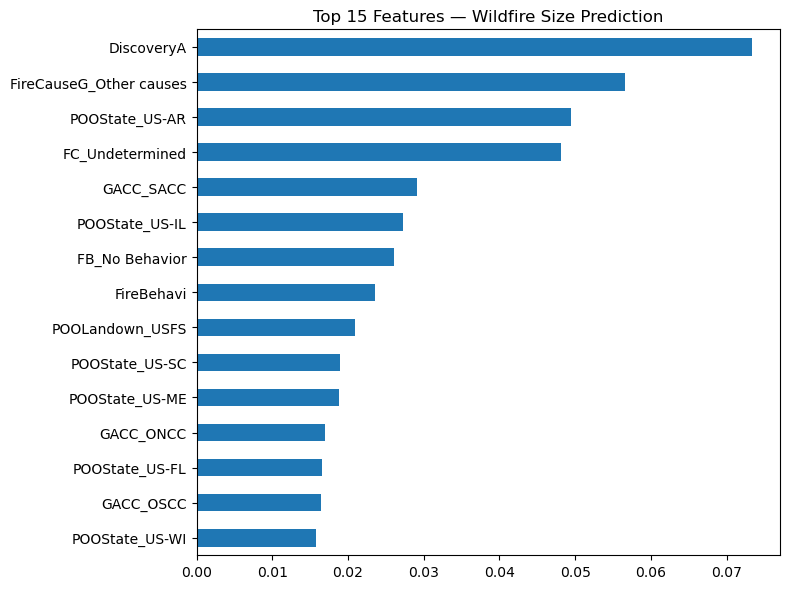

In [ ]:
# plotting most important features from XGBoost model
importances = pd.Series(clf_xgb.feature_importances_, index=X.columns)
importances.nlargest(15).sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 Features — Wildfire Size Prediction')
plt.tight_layout()
plt.show()

In [ ]:
# saving the model to be integrated into API

joblib.dump(clf_xgb, 'wildfire_model.pkl')

# Save the exact feature columns the model was trained on
feature_cols = X.columns.tolist()
with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

# Save the category options for each categorical input
category_options = {
    'POOState': df['POOState'].unique().tolist() if 'POOState' in df.columns else [],
    'GACC': sorted(df['GACC'].replace(' ', 'Unknown').unique().tolist()),
    'POOLandown': sorted(df['POOLandown'].replace(' ', 'Unknown').unique().tolist()),
    'FireCause': sorted(df['FireCause'].replace(' ', 'Undetermined').unique().tolist()),
    'FireCauseG': sorted(df['FireCauseG'].replace(' ', 'Undetermined').replace('Undetermined (remarks required)', 'Other causes').unique().tolist()),
    'FireBeha_2': sorted(df['FireBeha_2'].replace(' ', 'No Behavior').unique().tolist()),
    'FireBeha_3': sorted(df['FireBeha_3'].replace(' ', 'No Behavior').unique().tolist()),
    'PrimaryFue': sorted(df['PrimaryFue'].replace(' ', 'Undetermined').unique().tolist()),
    'SecondaryF': sorted(df['SecondaryF'].replace(' ', 'Undetermined').unique().tolist()),
    'season': ['Spring', 'Summer', 'Fall', 'Winter']
}

with open('category_options.json', 'w') as f:
    json.dump(category_options, f)

print("All files saved")

All files saved


As we can see, by using XGBoost, we can accurately predict the wildfire size class 83% of the time, with a weighted F1 score of 0.82. This is significant improvement from what I originally created back in the day, where I tried to use a linear regression model to predict the exact, continuous size of the fire. This is more accurate and has better application than the old model, as predicting the class can help determine what type of support is needed. Moreover, although the XGBoost model was the best, the Random Forest model had a similar accuracy of 79%. This is worse, however the interpretability of a random forest model is much higher than that of XGBoost. When applying this model to real life situations with wildland firefighters, situation unit leaders, etc. in a wildfire, it may be more beneficial to use the random forest, as it can be understood by non technical individuals. There could be more trust in the model that is easily interpretable, and thus would be more effective in being used among actual firefighters.